METRICHE PER VALUTARE I MODELLI GENERATIVI: FID E INCEPTION SCORE

Come si da un voto ad un sogno? 

Nei modelli generativi non basta guarda la loss.
Se una GAN genera immagini, devi rispondere a due domande:
1) le immagini sembrano reali?
2) sono abbastanza varie oppure il modello genera sempre cose simili?

FID e Inception Score cercano di misurasre proprio questo

L'idea generale:
Se ha un classificatore, hai metriche chiare: accuracy, precione, recall, f1
Per un generatore invece non ha una 'risposta corretta' unica.
Se chiedi: "genera un gatto" possono esistere migliaia di immagini corrette.
Quindi serve confrontare la distribuzione della immagini generate con quelle della immagini reali.
Il giudizio estetico è stato trasformato in puro calcolo statistico

** Inception Score (IS) **

Immagina di essere i giudici di una mostra d'arte prodotta da robot.
IS nasce proprio da questa necessità, valutare un modello generativo
L'idea è stata quella di aggiungere un altra ai preaddestrata per riconoscere il mondo, per fare da giudice.

L'inception score usa una rete già addestrata, normalmente Inception v3
Prende un'immagine generate
immegine -> inception - probabilità delle classi
Per esempio:
gatto = 0.95
cane = 0.02
auto = 0.01
altro = 0.2
Questa immagine viene considerata 'buona' perchè il modello è sicuro, è un gatto.
Se invece ottieni:
gatto = 0.20
cane = 0.18
auto = 0.15
cavallo = 0.14
...
l'immagine probabilmente è poco chiara o poco realistica
Ma non basta
Supponiamo che il generatore produca 10.000 immagini tutte di gatti perfetti.
Il classificatore sarebbe sicuro:
gatto = 0.99
ma il generatore avrebbe pochissima varietà
Quindi Incetpion Score considera anche la diversità globale
Vuole contemporaneamente:
    singola immagine -> classificazione molto sicura
    insieme delle immagini -> molte classi differenti

Vogliamo bassa entropia per la singola immagine (certezza della classe) e alta entropia per il dataset totale (varietà delle classi), se guardo 1000 foto voglio vedere tante classi diverse (non una ripetizione di una sola classe)
IS combina questi due aspetti in un unico numero

Quindi IS cerca di premiare: qualità (nitidezza) + diversità

In genere IS alto=meglio
quindi IS=2 è peggiore di IS=8
ma attenzione, questi numeri non sono confrontabili in assoluto tra dataset e implementazioni diverse.

Il limite principalre dell'Inception Score è che guarda solo le immagini generate.
Non confronta immagini reali vs immagini generate

Questo è un problema serie
immagina di avere un dataset composto solo da scarpe
ma il modello genera immagini perfette di cani, gatti, automobili.
L'Inception Score potrebbe anche essere buono, perchè le immagini sono nitide e diversa. Ma il generatore non sta riproducendo la distribuzione del dataset.

** Frechet Inception Distance (FID) **

FID confronta direttamente: immagini reali vs immagini generate

Prima prende le immagini reali
immagini reali - inception - feature
poi fa lo setsso con le immagini generate
immagini generate - inception - feature
non guarda direttamente i pixel, guarda le rappresentazioni interne della rete inceptio

Es.
Un immagine non viene vista come un insieme di pixel ma come un vettore di caratteristiche che rappresenta le proprietà più semantiche dell'immagine.
Poi FID contronfa la distribuzione delle feature reali con quelle delle feature genereate.
Se le due distribuzioni sono molto simili -> FID basso
Se le due distribuzione sono molto diverse -> FID alto
Quindi FID basso = meglio (opposto di IS)

FID rappresenta le due distrbuzioni (immagine reale e immagine generata) di feature attraverso media + covarianza
Quind non guarda soltanto l'immagine media ma anche come sono distribuite le immagini.
FID misura quanto la distribuzione generata assomiglia alla distribuzione rela.e

Supponiamo che il dataset reale abbia cani, gatti, cavalii
il generatore produca solo cani anche se perfetti.
Le feature generate occuperanno solo una piccola parte dello spazio reale.
Qindi FID peggiora
Questo permette di intercettare in parte problemi come: ode collapse

Le immagini vengono passate attraveso un livello intermedio di una rete neurtale per estrarre vettori di caratteristiche ad alta dimensione.
Si assume che queste caratteristiche seguano una distribuzione gaussiana multidimensionale per entrambi i gruppi
La distanza viene calcolata confrontando i vettori medi e le matrici di covarianza dei dati reali e di quelli sintetici.
Un valor eFID più basso indica una maggiore somiglianza tra le distribuzioni, suggerendo una generazione più realistica.

I limiti delle macchine e l'occhio umano
Nessuna singola formula matematica può catturare perfettamente l'essenza della bellezza o della plausibilità
I testo soggettivi (umani) rimangono un pilastro fondamentale nello sviluppo dei modelli generativi allo stato dell'arte (anno 2026)

Il Test di Turing Visivo
Il giudizio umano come verità fondamentale
- La valutazione umana permette di identificare errori logici e anatomici che le metriche statistiche ignorano
- I test di preferenza mettono a confronto diretto gli output di diversi modelli per stabilire quale sia più gradevole
- Le metriche automatiche possono essere ottimizzate artificialmente senza un reale miglioramento della qualità visiva.
- Un buon ricercatore deve sempre bilanciare i risultati dei punteggi numerici con un'ispezioe visiva rigorosa del dataset generato.

Ma attenzione, anche l'occio umano può essere ingannato e le metriche hanno delle trappole

Una delle trappole più pericolose è la memorizzazione del training set, quando un modello copia i dati reali, otterrà ottimi punteggi FID, pur non essendo realmente generativo.
Le reti pre-addestrate usate per FID e IS portano con sè i pregiudizi del dataset su cui sono state create originariamente (Bias dei Classificatori).
Se usi un cristico addestrato solo su foto occidentali, per valutare per esempio, l'arte di altre cultura, il giudizio sarà distorto
Il calcolo della FID richiede l'inferenza di migliaria di immagini, rendendo il monitoraggio frequente durante l'addestramento molto costoso.

Come comportarsi in un progetto reale?
La regola d'oro è l'onesta intelletuale.
Si consiglia di riportare sempre più metriche e di includere ampi set di immagini generate casualmente nei paper scientifici (non scelti tra i migliori).
L'uso di benchmark standarizzati permette alla comunità di confrontare i progressi in modo onesto e trasparente.


Addestramento del Giudice in corso (Estrazione delle caratteristiche)...
Epoch 1/2
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - loss: 1.6102
Epoch 2/2
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - loss: 1.0261


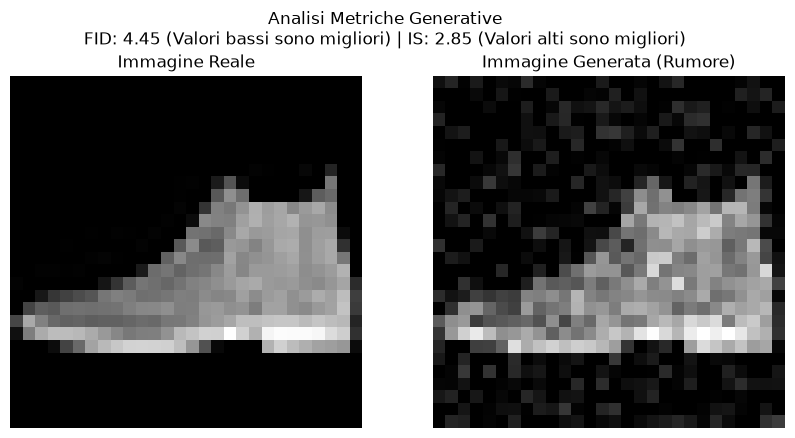

In [1]:
import os

# 1. CONFIGURAZIONE DEL BACKEND
# Impostiamo PyTorch come motore di calcolo per Keras prima di importare la libreria.
# Questa impostazione determina come verranno gestiti i tensori e le operazioni matematiche.
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers, ops
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

# 2. CARICAMENTO E PREPARAZIONE DEL DATASET
# Utilizziamo Fashion MNIST per addestrare un modello "Giudice" che sappia distinguere i capi d'abbigliamento.
# Questo modello servirà poi come base per misurare la qualità di immagini generate.
(x_train, y_train), (x_test, _) = keras.datasets.fashion_mnist.load_data()

# Normalizzazione: trasformiamo i valori dei pixel da [0, 255] a [0, 1] per facilitare la convergenza del modello.
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Aggiungiamo la dimensione del canale (grigio) per conformarci allo standard (Batch, Altezza, Larghezza, Canali).
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Le etichette vengono convertite in int32, formato richiesto dalla funzione di perdita per la classificazione.
y_train = y_train.astype("int32")

# 3. DEFINIZIONE DELL'ARCHITETTURA DEL GIUDICE
# Creiamo un modello con la Functional API di Keras che restituisce due diversi tipi di output.
def build_judge():
    inputs = keras.Input(shape=(28, 28, 1))
    
    # Strati convoluzionali per estrarre le caratteristiche spaziali dell'immagine.
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    
    # GlobalAveragePooling riduce l'immagine a un vettore di caratteristiche salienti, 
    # eliminando la dipendenza dalla posizione specifica degli oggetti.
    x = layers.GlobalAveragePooling2D()(x)
    
    # Primo Output: Feature profonde (Vettore di 64 elementi).
    # Queste rappresentano "l'essenza" dell'immagine e verranno usate per il calcolo della FID (Distanza di Fréchet).
    features = layers.Dense(64, activation="relu", name="out_features")(x)
    
    # Secondo Output: Probabilità di classe (10 classi).
    # Rappresenta quanto il modello è sicuro dell'appartenenza a una categoria.
    # Verrà usato per calcolare l'Inception Score (IS).
    probs = layers.Dense(10, activation="softmax", name="out_probs")(features)
    
    # Il modello è configurato per restituire entrambi gli output simultaneamente.
    return keras.Model(inputs=inputs, outputs=[features, probs])

# Istanziamo il modello.
judge = build_judge()

# Compiliamo il modello associando la funzione di perdita solo al ramo delle probabilità.
# L'output delle feature non ha bisogno di una loss perché non vogliamo ottimizzarlo direttamente,
# ma ci serve solo estrarlo dopo che il modello ha imparato a classificare correttamente.
judge.compile(
    optimizer="adam",
    loss={
        "out_probs": "sparse_categorical_crossentropy",
        "out_features": None 
    }
)

print("Addestramento del Giudice in corso (Estrazione delle caratteristiche)...")
# Durante il fit, forniamo al modello i dati e i relativi target. 
# Dato che il modello ha due output, passiamo una lista di target:
# 1. Un array di zeri per 'out_features' (che viene ignorato dalla loss 'None').
# 2. Le etichette reali per 'out_probs' (usate per l'addestramento).
judge.fit(
    x=x_train, 
    y=[np.zeros((len(y_train), 64)), y_train], 
    epochs=2, 
    batch_size=256, 
    verbose=1
)

# 4. SIMULAZIONE DI UN MODELLO GENERATIVO
# Per testare le metriche senza dover addestrare una GAN, creiamo dei campioni "finti" 
# aggiungendo rumore casuale a immagini reali.
real_samples = x_test[:500]
noise_factor = 0.1
fake_samples = real_samples + noise_factor * np.random.normal(size=real_samples.shape)
fake_samples = np.clip(fake_samples, 0., 1.).astype("float32")

# 5. CALCOLO DELLA FID (FRÉCHET INCEPTION DISTANCE)
# La FID misura la distanza tra la distribuzione delle immagini reali e quelle generate.
# Un valore basso indica che le immagini generate hanno statistiche simili a quelle reali.
def get_fid(real_imgs, fake_imgs):
    # Passaggio 1: Estraiamo le feature profonde tramite il modello Giudice.
    # predict() restituisce sia le feature che le probabilità, noi prendiamo solo le prime.
    f_real, _ = judge.predict(real_imgs, verbose=0)
    f_fake, _ = judge.predict(fake_imgs, verbose=0)
    
    # Convertiamo i tensori PyTorch in array NumPy per i calcoli statistici.
    f_real = ops.convert_to_numpy(f_real)
    f_fake = ops.convert_to_numpy(f_fake)
    

    # Passaggio 2: Calcoliamo le statistiche (media e covarianza) per entrambe le distribuzioni.
    # mu1 e sigma1 rappresentano la distribuzione delle immagini reali nello spazio delle feature.
    # mu2 e sigma2 rappresentano la distribuzione delle immagini generate (fake).
    mu1, sigma1 = f_real.mean(axis=0), np.cov(f_real, rowvar=False)
    mu2, sigma2 = f_fake.mean(axis=0), np.cov(f_fake, rowvar=False)
    
    # Aggiungiamo un piccolo valore (epsilon) alla diagonale delle matrici di covarianza.
    # Questa tecnica di regolarizzazione serve a rendere le matrici definite positive,
    # evitando errori numerici o matrici singolari durante il calcolo della radice quadrata.
    sigma1 += np.eye(sigma1.shape[0]) * 1e-6
    sigma2 += np.eye(sigma2.shape[0]) * 1e-6

    
    # Passaggio 3: Calcoliamo la distanza tra le medie e il contributo delle covarianze.
    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    
    # Gestiamo eventuali componenti immaginarie dovute a imprecisioni nel calcolo della radice quadrata.
    if np.iscomplexobj(covmean): 
        covmean = covmean.real
    
    # Formula finale della Distanza di Fréchet.
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

# 6. CALCOLO DELL'INCEPTION SCORE (IS)
# L'IS valuta due aspetti: la chiarezza dell'immagine (deve appartenere chiaramente a una classe) 
# e la varietà (il modello deve generare tutte le classi del dataset).
def get_is(imgs):
    # Passaggio 1: Otteniamo le probabilità di classe (secondo output del Giudice).
    # Per ogni immagine, il modello restituisce un vettore di probabilità (p(y|x)).
    _, probs = judge.predict(imgs, verbose=0)
    
    # Passaggio 2: Calcoliamo la distribuzione marginale (p(y)).
    # Rappresenta la media delle predizioni su tutto il batch di immagini.
    # Se il modello genera immagini variegate, questa distribuzione dovrebbe essere uniforme (alta entropia).
    p_y = np.mean(probs, axis=0)
    
    # Passaggio 3: Calcolo della Divergenza di Kullback-Leibler (KL Divergence).
    # L'Inception Score si basa su due pilastri fondamentali:
    # 1. Nitidezza (Sharpness): ogni immagine deve essere classificata con alta confidenza (bassa entropia di p(y|x)).
    # 2. Diversità (Diversity): l'insieme delle immagini deve coprire tutte le classi (alta entropia di p(y)).
    # La divergenza KL tra p(y|x) e p(y) cattura entrambi: è alta se la predizione per la singola
    # immagine è molto diversa (più "specifica") rispetto alla media di tutte le immagini.
    kl_div = probs * (np.log(probs + 1e-10) - np.log(p_y + 1e-10))
    
    # Passaggio 4: Calcolo dello score finale.
    # Sommiamo la KL su ogni classe, ne facciamo la media su tutto il batch e applichiamo l'esponenziale.
    # Un valore IS elevato indica che le immagini sono sia nitide che varie.
    is_score = np.exp(np.mean(np.sum(kl_div, axis=1)))
    return is_score

# Esecuzione dei calcoli sulle metriche.
fid_score = get_fid(real_samples, fake_samples)
is_val = get_is(fake_samples)

# 7. VISUALIZZAZIONE DEI RISULTATI
# Creiamo un confronto visivo tra un'immagine reale e la sua versione rumorosa (simulata generata).
plt.figure(figsize=(10, 5))

# Immagine Reale
plt.subplot(1, 2, 1)
plt.imshow(real_samples[0].reshape(28,28), cmap='gray')
plt.title("Immagine Reale")
plt.axis("off")

# Immagine Generata (Simulata con rumore)
plt.subplot(1, 2, 2)
plt.imshow(fake_samples[0].reshape(28,28), cmap='gray')
plt.title("Immagine Generata (Rumore)")
plt.axis("off")

# Titolo complessivo con spiegazione rapida delle metriche:
# FID: più è bassa, più il set generato è fedele a quello reale.
# IS: più è alta, più le immagini sono nitide e variegate.
plt.suptitle(f"Analisi Metriche Generative\nFID: {fid_score:.2f} (Valori bassi sono migliori) | IS: {is_val:.2f} (Valori alti sono migliori)")
plt.show()